### Chatpter 1

### Common NLP tasks
- text/document classification
- sentiment anaysis
- information retrieval
- parts of speech tagging
- language detection and machine translation
- conversational agent (text based/speech based)
- knowledge graph and QA systems
- text summarization
- topic modelling
- text generation
- spell checking and grammar correction
- text parsing
- speech to text



### Aproaches to NLP
- Heuristic Methods (till 1990s) (rule-based)
   - Regular expression
   - Wordnet (lexical dictionary)
   - Open Mind common sense

   ### Advantages
   - Less error

- Machine Learning based methods (after 1990s) (data-based)
   ### Advantages
   - solves wide problems
   - ML WORKFLOW -> text to vectors conversion
   - Algorithms -> Naive Bayes, Logistic Regression, SVM, LDA, Hidden Markov Models

- Deep Learning based methods (from 2010)
   ### Advantages
   - store sequential information 
   - auto feature generation 
   - RNN
   - LSTM
   - GRU/CNN
   - Transformers
   - Autoencoders


### Challenges in NLP
- Ambiguity
- Contextual words
- Colloquialisms and slang
- Synonyms
- Irony, Sarcasm and tonal diff
- Spelling errors
- Creativity
- Diversity


In [40]:
# Chapter 2

## NLP Pipelines
- Data Acquisition
- Text Preparation
   - Text Cleanup
   - Basic Preprocessing
   - Advance 
- Feature Engineering
- Modelling
  - Model Building
  - Evaluation
- Deployment
  - Deployment
  - Monitoring
  - Model Update

---

### Points to remember
- Its not universal
- Deep learning pipelines are slightly different.
- Pipeline is non linear

---

### Data Acquisition
- Data Available
  - Table (Do next step preprocessing)
  - In Database (Data engineer will give data from datahouse by making datawarehouse.)
  - Less Data (Data augumentation ->  generate fake data from existed data by four types Synonyms and Bigram flip and back translate and additional noise)
- External data available
  - Public dataset
  - Web scrapping
  - API
  - PDF 
  - Image
  - Audio data
- Data Not available

---

### Text Preparation
- Basic Cleaning
  - By using Regular expression tags cleaning
  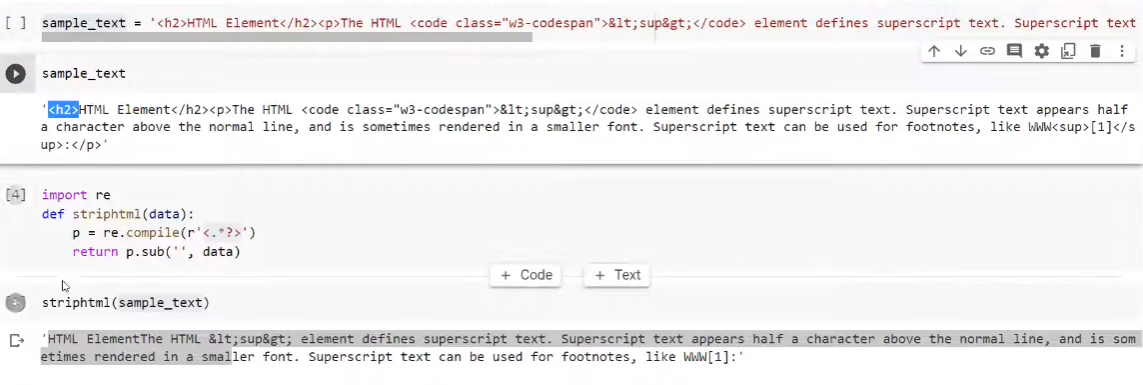
  - Unicode normalization (emoji to machine code)
  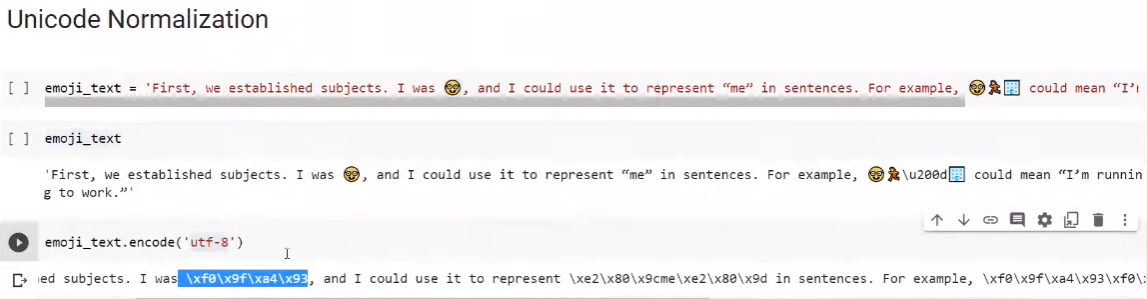
  - Spelling checking
  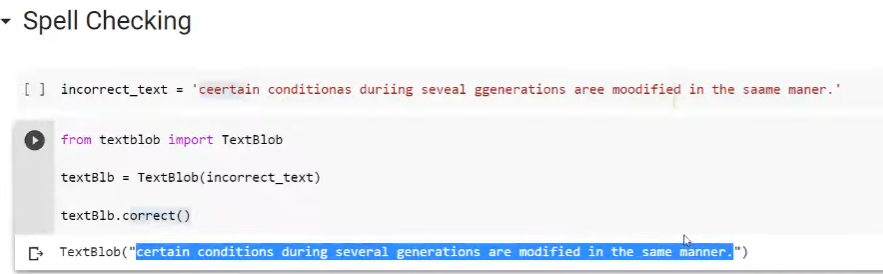

- Basic Text preprocessing
  - Basic 
    - Tokenization
      - Sentence
      - Word
  - Optional 
    - Stop words removal
    - Stemming
    - Lemmatization
    - Removing punctuation or digits
    - Lowercasing
    - Language detection

- Advance text preprocessing
  - Parts of speech tagging
  - Parsing
  - Co-reference resolution

---

### Feature Engineering
- Machine Learning Algorithm
  - Based on Domain knowledge
    #### Avantages
    - Outcome can be justified
    #### Disadvantages
    - Needed domain knowledge
    - Sometimes feature loss occurs

- Deep Learning Algorithm
  - By embedding (auto)
    #### Advantages
    - No need domain knowledge
    - Feature generated by DL model
    #### Disadvantages
    - Less Accurate (Loss Interpretion)

---

### Modelling
- Modelling (Which Model to apply, Depend on Amount of data and Nature of problem)
  - Heuristic
  - ML algorithm
  - DL algorithm
  - Cloud API

- Evaluation
  - Intrinsic (at technical level)
  - Extrinsic (at business(user) level)

---

### Deployment
- Deploy
  - API (microservice)
  - Chatbot
- Monitoring
- Update (Retrain)

---

### Assignment

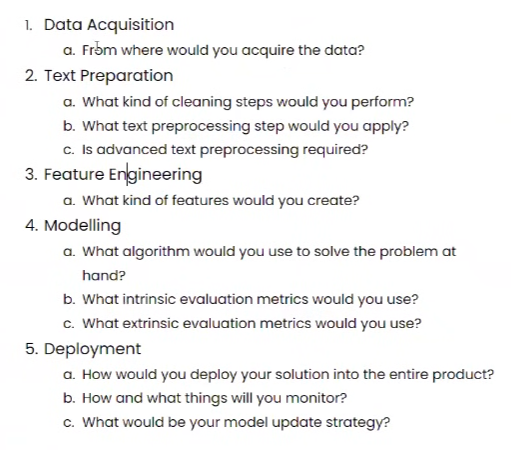






In [41]:
# Chapter 3

### Text Preprocessing
- Lowercasing
- Remove HTML tags
- Remove URLs
- Remove Punctuations
- Chat word treatment
- Spelling Correction
- Removing stop words
- Handling Emojis
- Tokenization
- Stemming
- Lemmatization

In [42]:
import pandas as pd

df = pd.read_csv("review/Train.csv")

df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


### Lowercasing 

In [43]:
# Lowercasing
df["text"][3].lower()

'even though i have great interest in biblical movies, i was bored to death every minute of the movie. everything is bad. the movie is too long, the acting is most of the time a joke and the script is horrible. i did not get the point in mixing the story about abraham and noah together. so if you value your time and sanity stay away from this horror.'

In [44]:
# Lowercasing whole data
df["text"] = df["text"].str.lower()
print(df)

                                                    text  label
0      i grew up (b. 1965) watching and loving the th...      0
1      when i put this movie in my dvd player, and sa...      0
2      why do people who do not know what a particula...      0
3      even though i have great interest in biblical ...      0
4      im a die hard dads army fan and nothing will e...      1
...                                                  ...    ...
39995  "western union" is something of a forgotten cl...      1
39996  this movie is an incredible piece of work. it ...      1
39997  my wife and i watched this movie because we pl...      0
39998  when i first watched flatliners, i was amazed....      1
39999  why would this film be so good, but only gross...      1

[40000 rows x 2 columns]


### Remove HTML Tags

In [45]:
# Using Regex
import re

def remove_html_tags(text):
  pattern = re.compile('<.*?>')
  return pattern.sub(r'', text)

remove_html_tags(text = "<h1>Hello</h1> <br> This movie was awesome!")

'Hello  This movie was awesome!'

In [46]:
df["text"] = df["text"].apply(remove_html_tags)
print(df.head())

                                                text  label
0  i grew up (b. 1965) watching and loving the th...      0
1  when i put this movie in my dvd player, and sa...      0
2  why do people who do not know what a particula...      0
3  even though i have great interest in biblical ...      0
4  im a die hard dads army fan and nothing will e...      1


### Remove URLs

In [47]:
text = "I loved this movie! You can read more reviews at https://www.imdb.com/title/tt0111161/"

def remove_url(text):
  pattern = re.compile(r"https?://\S+|www\.\S+")
  return pattern.sub(r"", text)

print(remove_url(text))

I loved this movie! You can read more reviews at 


### Remove Punctuations


In [48]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [50]:
exclude = string.punctuation

def remove_punc(text):
  for char in exclude:
    text = text.replace(char, "")
  return text

df["text"] = df["text"].apply(remove_punc)
print(df.head())

# efficient
def remove_punc(text):
  return text.translate(str.maketrans("", "", exclude)) 

                                                text  label
0  i grew up b 1965 watching and loving the thund...      0
1  when i put this movie in my dvd player and sat...      0
2  why do people who do not know what a particula...      0
3  even though i have great interest in biblical ...      0
4  im a die hard dads army fan and nothing will e...      1


### Chat Word treatment

In [55]:
# eg - fyi, gn, asap (shorthands)

chat_words = {
  "ASAP": "As soon as possible"
}

def chat_conversion(text):
  new_text = []
  for word in text.split():
    if word.upper() in chat_words:
      new_text.append(chat_words[word.upper()])
    else:
      new_text.append(word)
  return " ".join(new_text)

print(chat_conversion("Do this ASAP FYI!"))
 

Do this As soon as possible FYI!


### Spelling Correction

In [57]:
from textblob import TextBlob

text = "I definately reccomend this moovie. "

textBlb = TextBlob(text)

print(textBlb.correct().string)

I definitely recommend this movie. 


### Removing Stop words

In [67]:
# eg - a, the, am, are, not
from nltk.corpus import stopwords

stopword = set(stopwords.words("english"))

text = "This is a very good movie and I really enjoyed watching it"

words = text.split()

remove_stopwords = [word for word in words if word.lower() not in stopword]

print(remove_stopwords)


['good', 'movie', 'really', 'enjoyed', 'watching']


### Handling emojis

In [68]:
# Two type to convert it
# - Remove it
# - or replace it

import re

# To remove emoji
def remove_emoji(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)

    return emoji_pattern.sub(r'', text)

print(remove_emoji("I had an amazing day at the beach today! 🌞🏖️😎 We played volleyball 🏐, ate ice cream 🍦, and watched the sunset 🌅."))

I had an amazing day at the beach today!  We played volleyball , ate ice cream , and watched the sunset .


In [70]:
#  To replace emoji
import emoji
print(emoji.demojize("I had an amazing day at the beach today! 🌞🏖️😎 We played volleyball 🏐, ate ice cream 🍦, and watched the sunset 🌅."))


I had an amazing day at the beach today! :sun_with_face::beach_with_umbrella::smiling_face_with_sunglasses: We played volleyball :volleyball:, ate ice cream :soft_ice_cream:, and watched the sunset :sunrise:.


### Tokenization

Challenges in tokenization
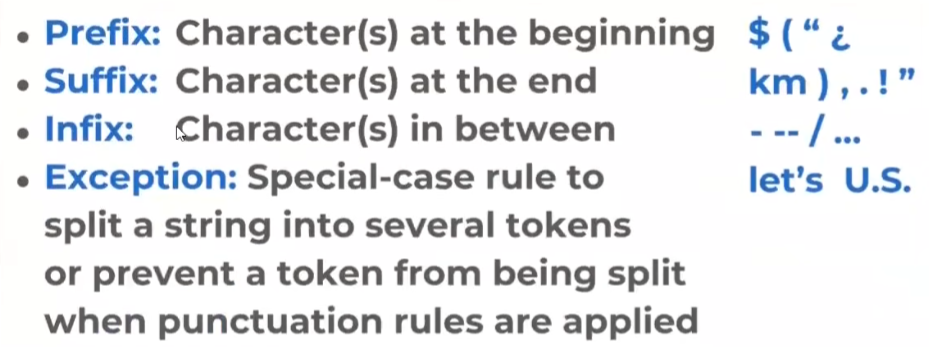

In [75]:
# Breaking text into smaller parts
# From paragraph into sentence
# From paragraph or sentence into words

# 1. Using the split function
# word tokenization
sent1 = "I am very good girl."
print(sent1.split())

# sentence tokenization
sent2 = "I am very good girl. I am very cute. I am very honest."
print(sent2.split("."))

# Using split('.') is not ideal because it:
# Leaves extra spaces.
# Creates empty strings.
# Fails with !, ?, abbreviations, etc.
 

['I', 'am', 'very', 'good', 'girl.']
['I am very good girl', ' I am very cute', ' I am very honest', '']


In [80]:
# 2. using Regular expression
import re

sent3 = "I am a good girl"
tokens = re.findall("[\w']+", sent3)
print(tokens)

# regular expression good for
# Quick word extraction	
# Cleaning text
# But not NLP aware

['I', 'am', 'a', 'good', 'girl']


<>:5: SyntaxWarning: invalid escape sequence '\w'
<>:5: SyntaxWarning: invalid escape sequence '\w'
C:\Users\91842\AppData\Local\Temp\ipykernel_19704\1990769623.py:5: SyntaxWarning: invalid escape sequence '\w'
  tokens = re.findall("[\w']+", sent3)


In [83]:
# 3. using nltk
from nltk.tokenize import word_tokenize, sent_tokenize

print(word_tokenize(sent3))
print(sent_tokenize(sent2))


['I', 'am', 'a', 'good', 'girl']
['I am very good girl.', 'I am very cute.', 'I am very honest.']


In [89]:
# 4. using spacy (its best)

import spacy
nlp = spacy.load("en_core_web_sm")

doc1 = nlp(sent1)
doc2 = nlp(sent2)
doc3 = nlp(sent3)

for token in doc2:
  print(token)


I
am
very
good
girl
.
I
am
very
cute
.
I
am
very
honest
.


### Stemming

In [93]:
from nltk.stem.porter import PorterStemmer

text = "The boys are playing football and running in the playground while their friends are studying"

ps = PorterStemmer()

stem_words = [ps.stem(word) for word in text.split()]
print(stem_words)

# stemmimg is fast

['the', 'boy', 'are', 'play', 'footbal', 'and', 'run', 'in', 'the', 'playground', 'while', 'their', 'friend', 'are', 'studi']


### Lemmatization

In [98]:
import nltk
from nltk.stem import WordNetLemmatizer

word_lemma = WordNetLemmatizer()

text = "The boys are playing football and running in the playground while their friends are studying"

stem_words = [word_lemma.lemmatize(word, pos = "v") for word in text.split()]
print(stem_words)

['The', 'boys', 'be', 'play', 'football', 'and', 'run', 'in', 'the', 'playground', 'while', 'their', 'friends', 'be', 'study']


### Asignment


In [ ]:
# Create dataset (multi-class classification - movies data(name, description, genre)) using TMDB API
# link -> https://api.themoviedb.org/3/movie/top_rated?api_key=8265bd1679663a7ea12ac168da84d2e8&language=en-US&page=471
# link of genre -> https://api.themoviedb.org/3/genre/movie/list?api_key=8265bd1679663a7ea12ac168da84d2e8&language=en-US
#  loop 1 to 471, fetch every movie in dataframe.
# Do Text preprocessing

In [1]:
# Chapter 4

### Text Representation or Feature Engineering
- One Hot Encoding
- Bag od Words
- N-grams
- TF-IDF
- Custom features
- Word2Vec (embeddings)


### Common Terms
- Corpus (Paragraphs or combination of words)
- Vocabulary (Unique words)
- Document (sentence or individual review)
- Word (individual word)

### One Hot Encoding
#### Pros
- Intuitive
- Easy to implement

#### Cons
- Sparsity
- No fixed size
- OOV
- No capturing of semantic meaning

### Bag of Words (BOW)
- Used for text classification problem a lot.

#### Pros
- Simple and Intuitive
- No fixed size needed

#### Cons
- Sparsity (Overfitting -> train random noise)
- OOV 
- Out of order


### Bag of N-grams (n-grams)
Token will contain 2 or 3 or 4 or n numbers of words rather than single word, to save sematic.
- Bi-gram
- Tri-gram
- Quad gram
- n-gram

#### Pros
- Able to capture sematic meaning
- Intuitive
- Easy to implement

#### Cons
- Due to dimention increase, time complexity increases (slows down the algo)
- OOV



### TF-IDF
TF -> Term frequency
IDF -> Inverse Document Frequency


TF(t,d) = No of occurence of term t in document d / Total number of terms in  document d

(0 < TF < 1)


IDF(t) = log(e) (Total number of documents in corpus / Number of documents with term t in them)

If term is frequent in corpus then IDF will be 0, and if term is rare in corpus then IDF will be high.

TF * IDF

#### Pros
- Mostly used in Information Retrieval (search engines)

#### Cons
- Sparsity
- OOV
- Dimensions very big (cause overfitting)
- No semantic capture

### Custom Features
- Number of positive words in the review
- Number of negative words in the review
- Ratio of positive/negative
- Word count
- char count


### Assignment
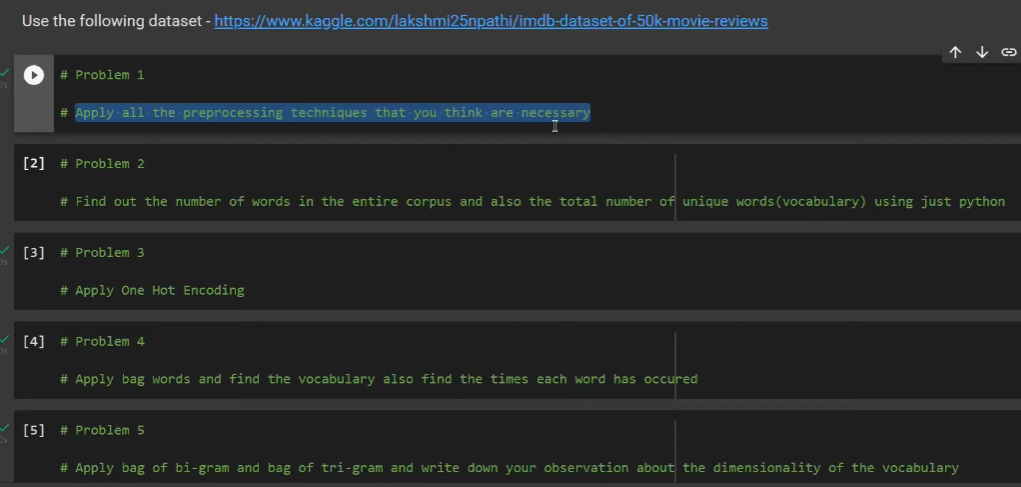
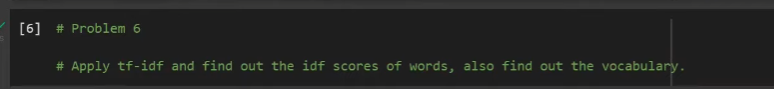